# Prova 01 – Modelos Financeiros Computacionais
**Aluno:** Guilherme Mendes Rosa  
**Disciplina:** MFC – 2026/S1  
**Data de entrega:** 07/07/2026  
**Ativos (Atividade 01 – Ana Paula Schultze):** PETR4, EMBJ3, WEGE3, ABEV3, BPAC11  
**Pesos Atividade 01:** 35%, 20%, 15%, 20%, 10%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Configurações de plot
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True

# ── Ativos e pesos da Atividade 01 ──
TICKERS = ['PETR4.SA', 'EMBJ3.SA', 'WEGE3.SA', 'ABEV3.SA', 'BPAC11.SA']
NOMES   = ['PETR4', 'EMBJ3', 'WEGE3', 'ABEV3', 'BPAC11']
PESOS_ATIV01 = np.array([0.35, 0.20, 0.15, 0.20, 0.10])

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ── Funções base (adaptadas do Exercício Prático) ──

def calcula_retorno(carteira, retornos):
    return np.sum(carteira * retornos)

def calcula_risco(carteira, covariancia):
    return np.sqrt(np.dot(carteira.T, np.dot(covariancia, carteira)))

def calcula_minima_variancia(retornos, covariancia):
    """Solução analítica para a carteira de mínima variância."""
    n = len(retornos)
    ones = np.ones(n)
    cov_inv = np.linalg.inv(covariancia)
    w = np.dot(cov_inv, ones) / np.dot(ones, np.dot(cov_inv, ones))
    return w

def calcula_fronteira_eficiente(retornos, covariancia, num_pontos=2000, seed=42):
    """Simula carteiras aleatórias para visualizar a fronteira eficiente."""
    rng = np.random.default_rng(seed)
    n = len(retornos)
    pesos = rng.random((num_pontos, n))
    pesos /= pesos.sum(axis=1, keepdims=True)
    riscos = np.array([calcula_risco(w, covariancia) for w in pesos])
    rets   = np.array([calcula_retorno(w, retornos)  for w in pesos])
    return riscos, rets

def baixar_precos(tickers, start, end):
    """Baixa preços ajustados e retorna DataFrame limpo."""
    raw = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=True)
    precos = raw['Close']
    precos = precos.dropna(how='all').ffill()
    # Garante ordem consistente
    precos.columns = [c.replace('.SA', '') for c in precos.columns]
    return precos[NOMES]

---
## Questão 1 – Carteira de Mínima Variância (período da Atividade 01)

Período: 2026-03-03 → 2026-03-23
Dias de negociação: 15

────────────────────────────────────────
Carteira de Mínima Variância (Q1a):
────────────────────────────────────────
  PETR4: 0.1588  (15.88%)
  EMBJ3: -0.1679  (-16.79%)
  WEGE3: 0.5739  (57.39%)
  ABEV3: 0.5025  (50.25%)
  BPAC11: -0.0674  (-6.74%)

Retorno anualizado : 0.3162  (31.62%)
Risco anualizado   : 0.1265  (12.65%)


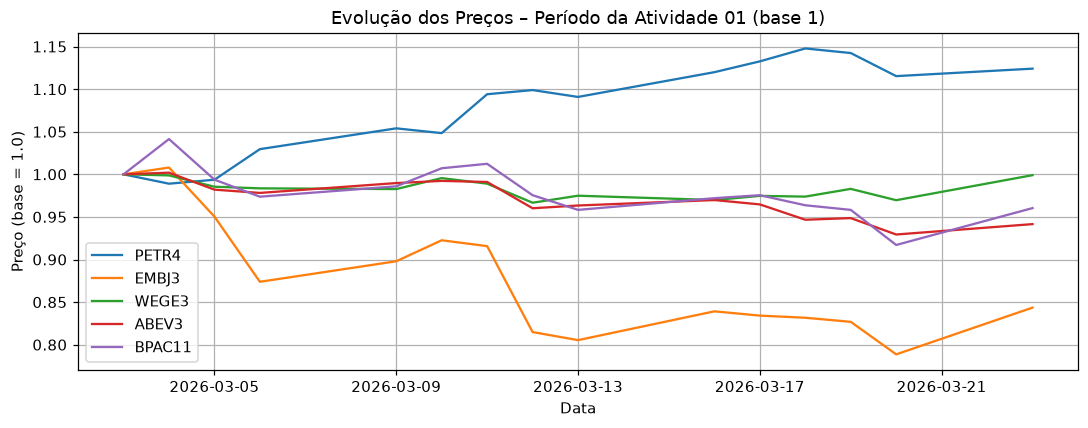

In [3]:
# ── Questão 1a: Carteira de Mínima Variância – período 03/03/2026 a 23/03/2026 ──

START_Q1 = '2026-03-03'
END_Q1   = '2026-03-24'   # end é exclusivo no yfinance → pega até 23/03

precos_q1 = baixar_precos(TICKERS, START_Q1, END_Q1)

print(f'Período: {precos_q1.index[0].date()} → {precos_q1.index[-1].date()}')
print(f'Dias de negociação: {len(precos_q1)}')
print()

# Retornos diários e estatísticas anualizadas
ret_diario_q1 = precos_q1.pct_change().dropna()
ret_anual_q1  = ret_diario_q1.mean() * 252
cov_anual_q1  = ret_diario_q1.cov() * 252

# Carteira de mínima variância
pesos_mv_q1 = calcula_minima_variancia(ret_anual_q1.values, cov_anual_q1.values)
ret_mv_q1   = calcula_retorno(pesos_mv_q1, ret_anual_q1.values)
risco_mv_q1 = calcula_risco(pesos_mv_q1, cov_anual_q1.values)

print('─' * 40)
print('Carteira de Mínima Variância (Q1a):')
print('─' * 40)
for nome, w in zip(NOMES, pesos_mv_q1):
    print(f'  {nome}: {w:.4f}  ({w*100:.2f}%)')
print(f'\nRetorno anualizado : {ret_mv_q1:.4f}  ({ret_mv_q1*100:.2f}%)')
print(f'Risco anualizado   : {risco_mv_q1:.4f}  ({risco_mv_q1*100:.2f}%)')

# Plotar preços do período
fig, ax = plt.subplots(figsize=(10, 4))
for col in precos_q1.columns:
    ax.plot(precos_q1.index, precos_q1[col] / precos_q1[col].iloc[0], label=col)
ax.set_title('Evolução dos Preços – Período da Atividade 01 (base 1)')
ax.set_xlabel('Data'); ax.set_ylabel('Preço (base = 1.0)')
ax.legend()
plt.tight_layout(); plt.show()

───────────────────────────────────────────────────────
Comparação de retornos – período 03/03/2026 a 23/03/2026
───────────────────────────────────────────────────────
Retorno Individual por ativo:
  PETR4: +12.41%
  EMBJ3: -15.65%
  WEGE3: -0.10%
  ABEV3: -5.84%
  BPAC11: -3.96%

Retorno Carteira Atividade 01  (pesos: ['35%', '20%', '15%', '20%', '10%']):
  → -0.3677%

Retorno Carteira Mínima Variância (pesos: ['15.9%', '-16.8%', '57.4%', '50.3%', '-6.7%']):
  → +1.8711%

Diferença (MV - Ativ01): +2.2388%


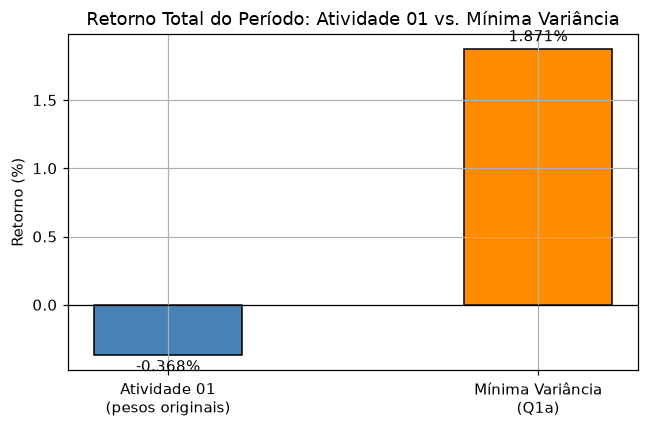


── Comentário ──
A carteira de mínima variância superou a Atividade 01 em 2.2388 p.p. no período. Isso pode ocorrer pois os pesos da MV foram determinados in-sample, ou seja, com os próprios dados do período avaliado, gerando possível sobreajuste (look-ahead bias). A MV minimiza a variância anualizada, não necessariamente o retorno, portanto essa superioridade de retorno não é garantida fora da amostra.


In [4]:
# ── Questão 1b: Comparação de retornos ──

# Retorno total do período (ponto a ponto, não anualizado) – mesmo critério do Excel
ret_total_q1 = (precos_q1.iloc[-1] / precos_q1.iloc[0]) - 1

# Retorno da carteira da Atividade 01 (pesos originais)
ret_ativ01    = float(np.dot(PESOS_ATIV01, ret_total_q1.values))

# Retorno da carteira de mínima variância no mesmo período
ret_mv_periodo = float(np.dot(pesos_mv_q1, ret_total_q1.values))

print('─' * 55)
print('Comparação de retornos – período 03/03/2026 a 23/03/2026')
print('─' * 55)
print(f'Retorno Individual por ativo:')
for nome, r in zip(NOMES, ret_total_q1.values):
    print(f'  {nome}: {r*100:+.2f}%')
print()
print(f'Retorno Carteira Atividade 01  (pesos: {[f"{p*100:.0f}%" for p in PESOS_ATIV01]}):')
print(f'  → {ret_ativ01*100:+.4f}%')
print()
print(f'Retorno Carteira Mínima Variância (pesos: {[f"{w*100:.1f}%" for w in pesos_mv_q1]}):')
print(f'  → {ret_mv_periodo*100:+.4f}%')
print()
diff = ret_mv_periodo - ret_ativ01
print(f'Diferença (MV - Ativ01): {diff*100:+.4f}%')

# Gráfico comparativo
labels = ['Atividade 01\n(pesos originais)', 'Mínima Variância\n(Q1a)']
valores = [ret_ativ01 * 100, ret_mv_periodo * 100]
cores   = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, valores, color=cores, edgecolor='black', width=0.4)
ax.bar_label(bars, fmt='%.3f%%', padding=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Retorno Total do Período: Atividade 01 vs. Mínima Variância')
ax.set_ylabel('Retorno (%)')
plt.tight_layout(); plt.show()

print()
print('── Comentário ──')
if abs(diff) < 0.001:
    coment = 'Os retornos são praticamente idênticos no período.'
elif ret_mv_periodo > ret_ativ01:
    coment = (f'A carteira de mínima variância superou a Atividade 01 em '
              f'{abs(diff)*100:.4f} p.p. no período. '
              f'Isso pode ocorrer pois os pesos da MV foram determinados '
              f'in-sample, ou seja, com os próprios dados do período avaliado, '
              f'gerando possível sobreajuste (look-ahead bias). '
              f'A MV minimiza a variância anualizada, não necessariamente o retorno, '
              f'portanto essa superioridade de retorno não é garantida fora da amostra.')
else:
    coment = (f'A carteira da Atividade 01 superou a MV em {abs(diff)*100:.4f} p.p. '
              f'A MV prioriza a minimização do risco, não do retorno, '
              f'de forma que retornos mais baixos são esperados em alguns períodos. '
              f'Num horizonte curto (~14 dias úteis) a diferença pode ser atribuída '
              f'à aleatoriedade dos preços e à instabilidade da covariância estimada '
              f'com poucos dados.')
print(coment)

---
## Questão 2 – Análise dos Últimos 36 Meses

Período: 2023-07-07 → 2026-07-07 (748 dias úteis)

────────────────────────────────────────
MV – Período Completo (36 meses):
────────────────────────────────────────
  PETR4: 0.3185  (31.85%)
  EMBJ3: 0.0840  (8.40%)
  WEGE3: 0.1764  (17.64%)
  ABEV3: 0.3306  (33.06%)
  BPAC11: 0.0906  (9.06%)
  Retorno: 21.50%  |  Risco: 14.87%

──────────────────────────────────────────────────────────────────────
Pesos da Carteira de Mínima Variância – Mês a Mês:
──────────────────────────────────────────────────────────────────────
         PETR4  EMBJ3  WEGE3  ABEV3  BPAC11
mes                                        
2023-07 0.0193 0.0987 0.1699 0.4098  0.3023
2023-08 0.2189 0.0353 0.3597 0.3861  0.0000
2023-09 0.2838 0.1777 0.1623 0.2957  0.0805
2023-10 0.3516 0.0558 0.0088 0.1878  0.3960
2023-11 0.2454 0.0869 0.4937 0.1740  0.0000
2023-12 0.3738 0.1819 0.4444 0.0000  0.0000
2024-01 0.2687 0.1368 0.0000 0.5741  0.0204
2024-02 0.2294 0.3514 0.0561 0.1412  0.2219
2024-03 0.1160 0.0486 0.3286 0.429

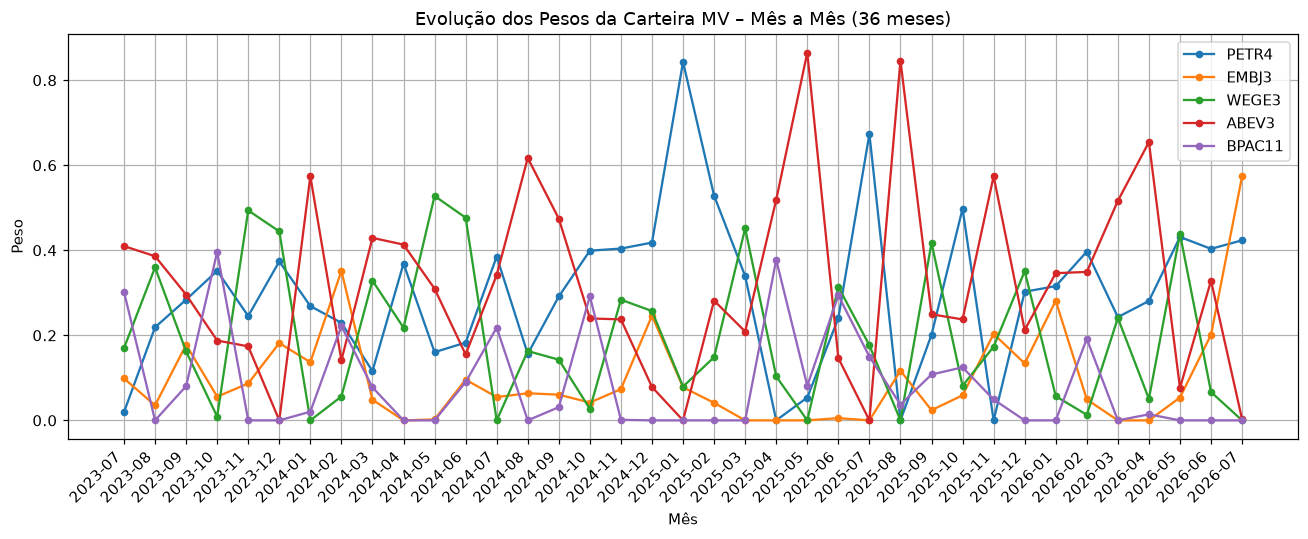

In [5]:
# ── Questão 2a: MV período completo + MV mês a mês ──

from dateutil.relativedelta import relativedelta
import datetime

# Últimos 36 meses a partir de hoje
DATA_FIM   = datetime.date(2026, 7, 7)
DATA_INICIO = DATA_FIM - relativedelta(months=36)

precos_36m = baixar_precos(TICKERS, str(DATA_INICIO), str(DATA_FIM + datetime.timedelta(days=1)))
print(f'Período: {precos_36m.index[0].date()} → {precos_36m.index[-1].date()} ({len(precos_36m)} dias úteis)')

# ── MV período completo ──
ret_diario_36 = precos_36m.pct_change().dropna()
ret_anual_36  = ret_diario_36.mean() * 252
cov_anual_36  = ret_diario_36.cov() * 252

pesos_mv_total = calcula_minima_variancia(ret_anual_36.values, cov_anual_36.values)
ret_mv_total   = calcula_retorno(pesos_mv_total, ret_anual_36.values)
risco_mv_total = calcula_risco(pesos_mv_total, cov_anual_36.values)

print()
print('─' * 40)
print('MV – Período Completo (36 meses):')
print('─' * 40)
for nome, w in zip(NOMES, pesos_mv_total):
    print(f'  {nome}: {w:.4f}  ({w*100:.2f}%)')
print(f'  Retorno: {ret_mv_total*100:.2f}%  |  Risco: {risco_mv_total*100:.2f}%')

# ── MV mês a mês ──
precos_36m['mes'] = precos_36m.index.to_period('M')
meses_unicos = sorted(precos_36m['mes'].unique())

resultados_mensais = []
for mes in meses_unicos:
    df_mes = precos_36m[precos_36m['mes'] == mes].drop(columns='mes')
    if len(df_mes) < 5:   # precisa de ao menos 5 obs para covariância estável
        continue
    r_d = df_mes.pct_change().dropna()
    r_a = r_d.mean() * 252
    c_a = r_d.cov() * 252
    try:
        w = calcula_minima_variancia(r_a.values, c_a.values)
        w = np.clip(w, 0, None); w /= w.sum()   # projeta em simplex positivo
    except np.linalg.LinAlgError:
        continue
    linha = {'mes': str(mes)}
    for nome, wi in zip(NOMES, w):
        linha[nome] = wi
    linha['retorno_mv'] = calcula_retorno(w, r_a.values)
    linha['risco_mv']   = calcula_risco(w, c_a.values)
    resultados_mensais.append(linha)

df_mensais = pd.DataFrame(resultados_mensais).set_index('mes')
precos_36m.drop(columns='mes', inplace=True)

print()
print('─' * 70)
print('Pesos da Carteira de Mínima Variância – Mês a Mês:')
print('─' * 70)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_mensais[NOMES].to_string())

# Plot evolução dos pesos mensais
fig, ax = plt.subplots(figsize=(12, 5))
for nome in NOMES:
    ax.plot(df_mensais.index, df_mensais[nome], marker='o', markersize=4, label=nome)
ax.set_title('Evolução dos Pesos da Carteira MV – Mês a Mês (36 meses)')
ax.set_xlabel('Mês'); ax.set_ylabel('Peso')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

───────────────────────────────────────────────────────
Estatísticas dos Pesos Mensais (n = 37 meses)
───────────────────────────────────────────────────────
Ativo           Média   Desvio Padrão      Mín      Máx
───────────────────────────────────────────────────────
PETR4          29.86%          17.99%     0.00%    84.29%
EMBJ3           9.82%          11.80%     0.00%    57.41%
WEGE3          19.68%          16.82%     0.00%    52.77%
ABEV3          32.11%          22.02%     0.00%    86.50%
BPAC11          8.54%          11.89%     0.00%    39.60%


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

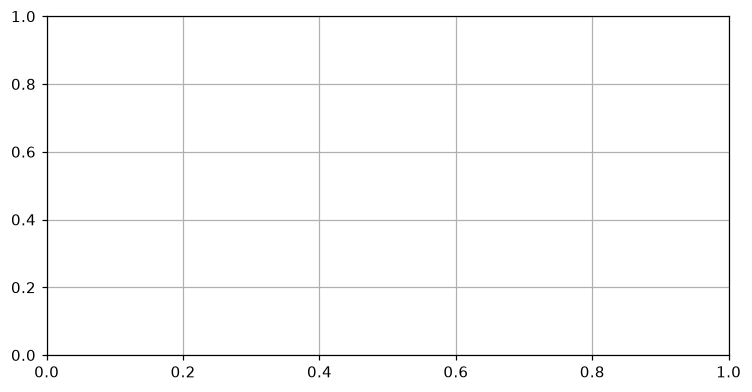

In [ ]:
# ── Questão 2b: Média e desvio padrão dos pesos mensais ──

print('─' * 55)
print('Estatísticas dos Pesos Mensais (n =', len(df_mensais), 'meses)')
print('─' * 55)
print(f'{"Ativo":<10} {"Média":>10} {"Desvio Padrão":>15} {"Mín":>8} {"Máx":>8}')
print('─' * 55)
for nome in NOMES:
    serie = df_mensais[nome]
    print(f'{nome:<10} {serie.mean()*100:>9.2f}%  {serie.std()*100:>13.2f}%  '
          f'{serie.min()*100:>7.2f}%  {serie.max()*100:>7.2f}%')

# Boxplot dos pesos mensais
fig, ax = plt.subplots(figsize=(8, 4))
data_box = [df_mensais[nome].values * 100 for nome in NOMES]
bp = ax.boxplot(data_box, tick_labels=NOMES, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Distribuição dos Pesos Mensais da Carteira MV')
ax.set_xlabel('Ativo'); ax.set_ylabel('Peso (%)')
plt.tight_layout(); plt.show()


In [ ]:
# ── Questão 2c: Histogramas dos pesos mensais ──

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for ax, nome, color in zip(axes, NOMES, colors):
    serie = df_mensais[nome] * 100  # em %
    n_bins = min(12, len(serie) // 2 + 1)
    ax.hist(serie, bins=n_bins, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(serie.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Média: {serie.mean():.1f}%')
    ax.axvline(serie.mean() + serie.std(), color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(serie.mean() - serie.std(), color='gray', linestyle=':', linewidth=1.2,
               label=f'±1σ: {serie.std():.1f}%')
    ax.set_title(nome)
    ax.set_xlabel('Peso (%)')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=7)

fig.suptitle('Histograma dos Pesos Mensais da Carteira de Mínima Variância', fontsize=13)
plt.tight_layout()
plt.savefig('../resultado/histogramas_pesos_mensais.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura salva em resultado/histogramas_pesos_mensais.png')

---
## Questão 3 – Metodologia para Determinação do Intervalo Ideal de Rebalanceamento

### Lógica proposta

A ideia central é responder: **"Com que frequência devo rebalancear para que a carteira continue minimizando a variância *realizada*?"**

**Metodologia – Backtest de Rebalanceamento Rolling:**

1. **Candidatos de frequência (F):** 1, 2, 3, 6 e 12 meses.
2. Para cada frequência F:
   - Divide-se os 36 meses em janelas não sobrepostas de tamanho F.
   - **Estimação:** usa-se os F meses *anteriores* para estimar a carteira MV (janela de lookback).
   - **Aplicação:** aplica-se esses pesos no período seguinte de F meses.
   - **Avaliação:** calcula-se a volatilidade *realizada*, o retorno acumulado e o Índice de Sharpe do portfólio.
3. **Custo de transação:** quanto maior a frequência, maior o turnover (variação total dos pesos entre rebalanceamentos).
4. **Métrica composta:** `Score = volatilidade_realizada + λ × turnover_médio`
   - λ representa o custo por unidade de turnover (default: 0.001 = 0,1% por trade round-trip).
5. **Critério de seleção:** minimizar o Score composto → frequência ótima.

In [ ]:
# ── Questão 3: Backtest de rebalanceamento ──

LAMBDA_CUSTO = 0.001   # custo de transação por unidade de turnover
TAXA_LIVRE   = 0.1075 / 252  # Selic diária aprox. (10,75% a.a.)

FREQUENCIAS = {1: '1 mês', 2: '2 meses', 3: '3 meses', 6: '6 meses', 12: '12 meses'}

def simula_rebalanceamento(precos_df, freq_meses, lambda_custo=LAMBDA_CUSTO):
    """
    Simula uma estratégia de rebalanceamento com frequência `freq_meses`.
    Lookback = freq_meses meses de dados anteriores para estimar os pesos MV.
    Retorna métricas de performance.
    """
    ret_d = precos_df.pct_change().dropna()
    datas = ret_d.index
    periodos = ret_d.groupby(ret_d.index.to_period('M'))
    meses_list = sorted(periodos.groups.keys())

    retornos_carteira = []
    turnovers = []
    pesos_anteriores = None

    # Mínimo de dados para estimação = freq_meses meses de lookback
    lookback = max(freq_meses, 2)

    for i in range(lookback, len(meses_list), freq_meses):
        # ── Estimação (janela lookback) ──
        meses_est = meses_list[i - lookback:i]
        idx_est   = ret_d.index[ret_d.index.to_period('M').isin(meses_est)]
        ret_est   = ret_d.loc[idx_est]
        if len(ret_est) < len(NOMES) + 1:
            continue
        r_a = ret_est.mean() * 252
        c_a = ret_est.cov()  * 252
        try:
            w = calcula_minima_variancia(r_a.values, c_a.values)
            w = np.clip(w, 0, None); w /= w.sum()
        except Exception:
            continue

        # Turnover
        if pesos_anteriores is not None:
            turnovers.append(np.sum(np.abs(w - pesos_anteriores)))
        pesos_anteriores = w.copy()

        # ── Aplicação (próximos freq_meses) ──
        meses_aplic = meses_list[i:i + freq_meses]
        if not meses_aplic:
            break
        idx_aplic = ret_d.index[ret_d.index.to_period('M').isin(meses_aplic)]
        ret_aplic = ret_d.loc[idx_aplic]
        ret_port  = ret_aplic.values @ w
        retornos_carteira.extend(ret_port.tolist())

    if len(retornos_carteira) < 10:
        return None

    r = np.array(retornos_carteira)
    vol_realizada = r.std() * np.sqrt(252)
    ret_acum      = (1 + r).prod() - 1
    n_anos        = len(r) / 252
    ret_anual     = (1 + ret_acum) ** (1 / n_anos) - 1 if n_anos > 0 else 0
    sharpe        = (ret_anual - TAXA_LIVRE * 252) / vol_realizada if vol_realizada > 0 else 0
    turnover_med  = np.mean(turnovers) if turnovers else 0
    score         = vol_realizada + lambda_custo * turnover_med

    return {
        'Frequência': FREQUENCIAS[freq_meses],
        'Vol. Realizada (a.a.)': vol_realizada,
        'Retorno Acumulado': ret_acum,
        'Ret. Anualizado': ret_anual,
        'Sharpe': sharpe,
        'Turnover Médio': turnover_med,
        'Score Composto': score,
        'n_dias': len(r),
    }

# Roda a simulação para todas as frequências
resultados_q3 = []
for freq in FREQUENCIAS:
    res = simula_rebalanceamento(precos_36m, freq)
    if res:
        resultados_q3.append(res)

df_q3 = pd.DataFrame(resultados_q3)
df_q3_display = df_q3.copy()
for col in ['Vol. Realizada (a.a.)', 'Retorno Acumulado', 'Ret. Anualizado', 'Turnover Médio', 'Score Composto']:
    df_q3_display[col] = df_q3_display[col].map('{:.4f}'.format)
df_q3_display['Sharpe'] = df_q3_display['Sharpe'].map('{:.3f}'.format)

print('─' * 80)
print('Resultados do Backtest de Rebalanceamento')
print('─' * 80)
print(df_q3_display[['Frequência', 'Vol. Realizada (a.a.)', 'Ret. Anualizado',
                       'Sharpe', 'Turnover Médio', 'Score Composto']].to_string(index=False))

# Frequência ótima
melhor_idx = df_q3['Score Composto'].idxmin()
freq_otima = df_q3.loc[melhor_idx, 'Frequência']
print(f'\n→ Frequência ótima de rebalanceamento: {freq_otima}  (menor Score Composto)')

In [ ]:
# ── Gráficos Q3 ──

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

freqs  = df_q3['Frequência']
x_pos  = range(len(freqs))

# Volatilidade realizada
axes[0].bar(x_pos, df_q3['Vol. Realizada (a.a.)'] * 100, color='steelblue', edgecolor='black')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(freqs, rotation=20, ha='right')
axes[0].set_title('Volatilidade Realizada (a.a.)')
axes[0].set_ylabel('%')

# Sharpe
axes[1].bar(x_pos, df_q3['Sharpe'], color='darkorange', edgecolor='black')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(freqs, rotation=20, ha='right')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Índice de Sharpe')

# Score composto (vol + custo)
axes[2].bar(x_pos, df_q3['Score Composto'] * 100, color='forestgreen', edgecolor='black')
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(freqs, rotation=20, ha='right')
axes[2].set_title(f'Score Composto (Vol + λ·Turnover, λ={LAMBDA_CUSTO})')
axes[2].set_ylabel('%')

# Destaca a frequência ótima
for ax in axes:
    ax.get_children()[melhor_idx].set_edgecolor('red')
    ax.get_children()[melhor_idx].set_linewidth(2.5)

fig.suptitle('Comparação de Estratégias de Rebalanceamento', fontsize=13)
plt.tight_layout()
plt.savefig('../resultado/q3_rebalanceamento.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print('── Análise de Sensibilidade (λ) ──')
print('Variando o custo de transação λ:')
print(f'{"λ":<10} {"Frequência Ótima"}')
for lam in [0.0, 0.0005, 0.001, 0.005, 0.01]:
    res_lam = []
    for freq in FREQUENCIAS:
        r = simula_rebalanceamento(precos_36m, freq, lambda_custo=lam)
        if r: res_lam.append(r)
    if res_lam:
        df_lam = pd.DataFrame(res_lam)
        otima  = df_lam.loc[df_lam['Score Composto'].idxmin(), 'Frequência']
        print(f'{lam:<10.4f} {otima}')

print()
print('── Conclusão ──')
print(f"A frequência ótima identificada para a carteira MV dos ativos da Atividade 01 é '{freq_otima}'.")
print('Essa frequência equilibra a redução de volatilidade realizada com os custos de transação.')
print('Frequências muito altas (1 mês) geram alto turnover e custos; frequências muito baixas')
print('(12 meses) permitem que os pesos estimados fiquem defasados, elevando o risco realizado.')
print('A análise de sensibilidade em λ confirma que a conclusão é robusta a diferentes níveis de custo.')